# Zajęcie 3 — Analiza skupień (Clustering)

**Zbiór danych:** Wine (UCI / sklearn) — 178 próbek, 13 cech chemicznych, 3 klasy odmian wina.

Zakres:
1. **PCA** — redukcja wymiarowości i wizualizacja skupień (2D/3D)
2. **k-means** — wybór optymalnego *k* metodą łokcia
3. **Klasteryzacja hierarchiczna** — porównanie metod łączenia (Ward, single, complete), dendrogramy


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Wczytanie danych
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y_true = wine.target  # rzeczywiste etykiety (tylko do porównania)
print('Rozmiar:', X.shape)
print('Klasy:', np.unique(y_true, return_counts=True))
X.head()


Rozmiar: (178, 13)
Klasy: (array([0, 1, 2]), array([59, 71, 48]))


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [2]:
# Standaryzacja danych (kluczowe dla PCA i k-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 1. PCA — redukcja wymiarowości i wizualizacja

In [3]:
# PCA do 2 oraz 3 składowych
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

print('Wariancja wyjaśniona (2 składowe):', pca2.explained_variance_ratio_, 
      f'-> łącznie {pca2.explained_variance_ratio_.sum():.3f}')
print('Wariancja wyjaśniona (3 składowe):', pca3.explained_variance_ratio_,
      f'-> łącznie {pca3.explained_variance_ratio_.sum():.3f}')


Wariancja wyjaśniona (2 składowe): [0.36198848 0.1920749 ] -> łącznie 0.554
Wariancja wyjaśniona (3 składowe): [0.36198848 0.1920749  0.11123631] -> łącznie 0.665


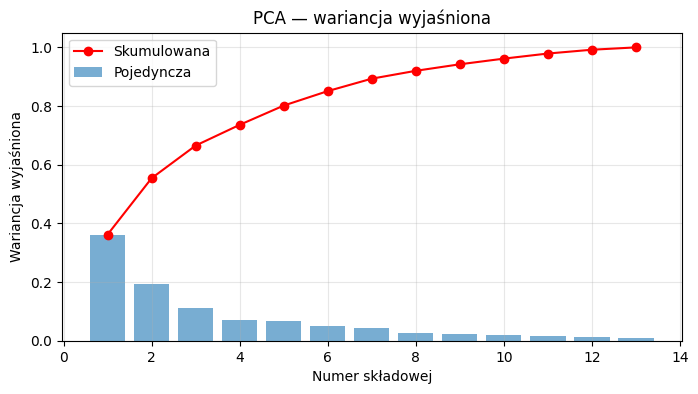

In [4]:
# Wykres osypiska (scree plot)
pca_full = PCA().fit(X_scaled)
plt.figure(figsize=(8,4))
plt.bar(range(1, len(pca_full.explained_variance_ratio_)+1),
        pca_full.explained_variance_ratio_, alpha=0.6, label='Pojedyncza')
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1),
         np.cumsum(pca_full.explained_variance_ratio_), 'ro-', label='Skumulowana')
plt.xlabel('Numer składowej'); plt.ylabel('Wariancja wyjaśniona')
plt.title('PCA — wariancja wyjaśniona')
plt.legend(); plt.grid(alpha=0.3); plt.show()


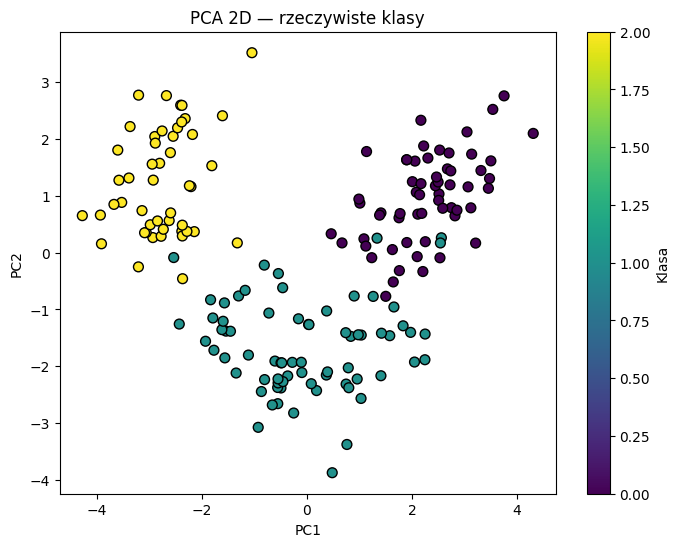

In [5]:
# Wizualizacja 2D wg rzeczywistych klas
plt.figure(figsize=(8,6))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=y_true, cmap='viridis', s=50, edgecolor='k')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCA 2D — rzeczywiste klasy')
plt.colorbar(label='Klasa')
plt.show()


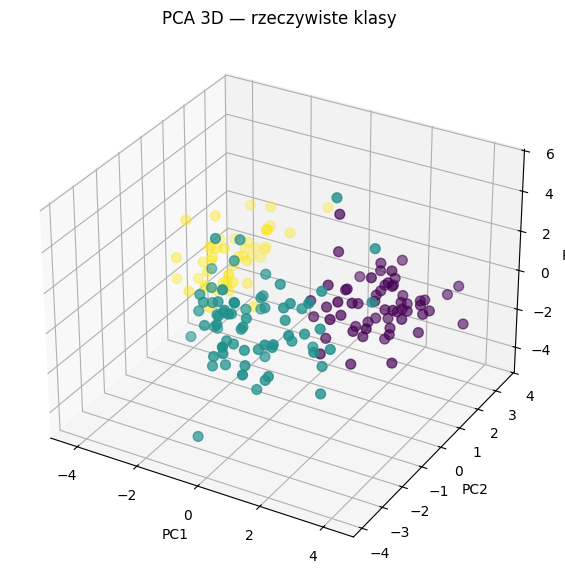

In [6]:
# Wizualizacja 3D
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=y_true, cmap='viridis', s=50)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('PCA 3D — rzeczywiste klasy')
plt.show()


### Porównanie klasteryzacji przed i po PCA

Silhouette (oryginalne, 13D): 0.285
Silhouette (po PCA, 2D):      0.561
ARI vs prawdziwe (oryginalne): 0.897
ARI vs prawdziwe (po PCA):    0.895


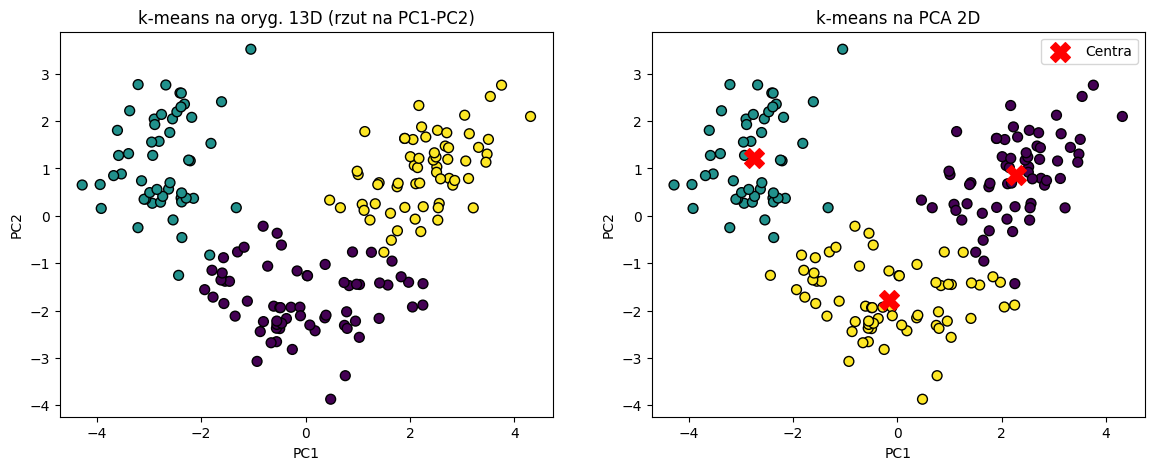

In [7]:
# k-means k=3 na danych oryginalnych (po standaryzacji) i po PCA
km_orig = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_scaled)
km_pca  = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_pca2)

print('Silhouette (oryginalne, 13D):', round(silhouette_score(X_scaled, km_orig.labels_), 3))
print('Silhouette (po PCA, 2D):     ', round(silhouette_score(X_pca2, km_pca.labels_), 3))
print('ARI vs prawdziwe (oryginalne):', round(adjusted_rand_score(y_true, km_orig.labels_), 3))
print('ARI vs prawdziwe (po PCA):   ', round(adjusted_rand_score(y_true, km_pca.labels_), 3))

fig, ax = plt.subplots(1, 2, figsize=(14,5))
ax[0].scatter(X_pca2[:,0], X_pca2[:,1], c=km_orig.labels_, cmap='viridis', s=50, edgecolor='k')
ax[0].set_title('k-means na oryg. 13D (rzut na PC1-PC2)')
ax[0].set_xlabel('PC1'); ax[0].set_ylabel('PC2')

ax[1].scatter(X_pca2[:,0], X_pca2[:,1], c=km_pca.labels_, cmap='viridis', s=50, edgecolor='k')
ax[1].scatter(km_pca.cluster_centers_[:,0], km_pca.cluster_centers_[:,1],
              c='red', marker='X', s=200, label='Centra')
ax[1].set_title('k-means na PCA 2D'); ax[1].legend()
ax[1].set_xlabel('PC1'); ax[1].set_ylabel('PC2')
plt.show()


## 2. k-means — metoda łokcia

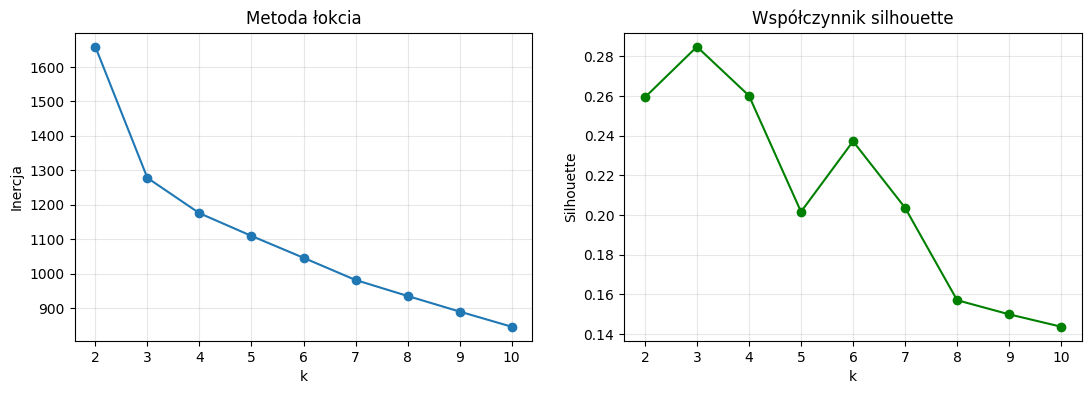

Najlepsze k wg silhouette: 3


In [8]:
# Metoda łokcia: inercja oraz silhouette dla różnych k
ks = range(2, 11)
inertias, silhs = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhs.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(ks, inertias, 'o-')
ax[0].set_xlabel('k'); ax[0].set_ylabel('Inercja')
ax[0].set_title('Metoda łokcia')
ax[0].grid(alpha=0.3)

ax[1].plot(ks, silhs, 'o-', color='green')
ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette')
ax[1].set_title('Współczynnik silhouette')
ax[1].grid(alpha=0.3)
plt.show()

print(f'Najlepsze k wg silhouette: {ks[np.argmax(silhs)]}')


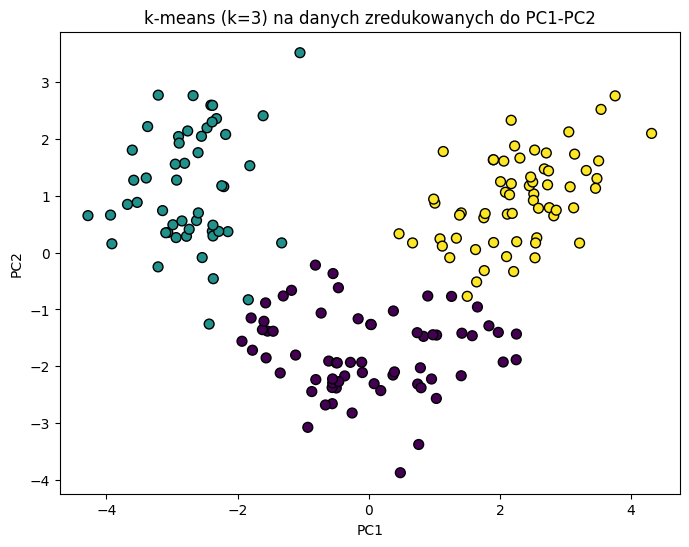

ARI vs prawdziwe etykiety: 0.897


In [9]:
# Optymalne k = 3 (zgodnie z łokciem i znaną liczbą klas)
k_opt = 3
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10).fit(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=km_final.labels_, cmap='viridis', s=50, edgecolor='k')
plt.title(f'k-means (k={k_opt}) na danych zredukowanych do PC1-PC2')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.show()

print(f'ARI vs prawdziwe etykiety: {adjusted_rand_score(y_true, km_final.labels_):.3f}')


## 3. Klasteryzacja hierarchiczna

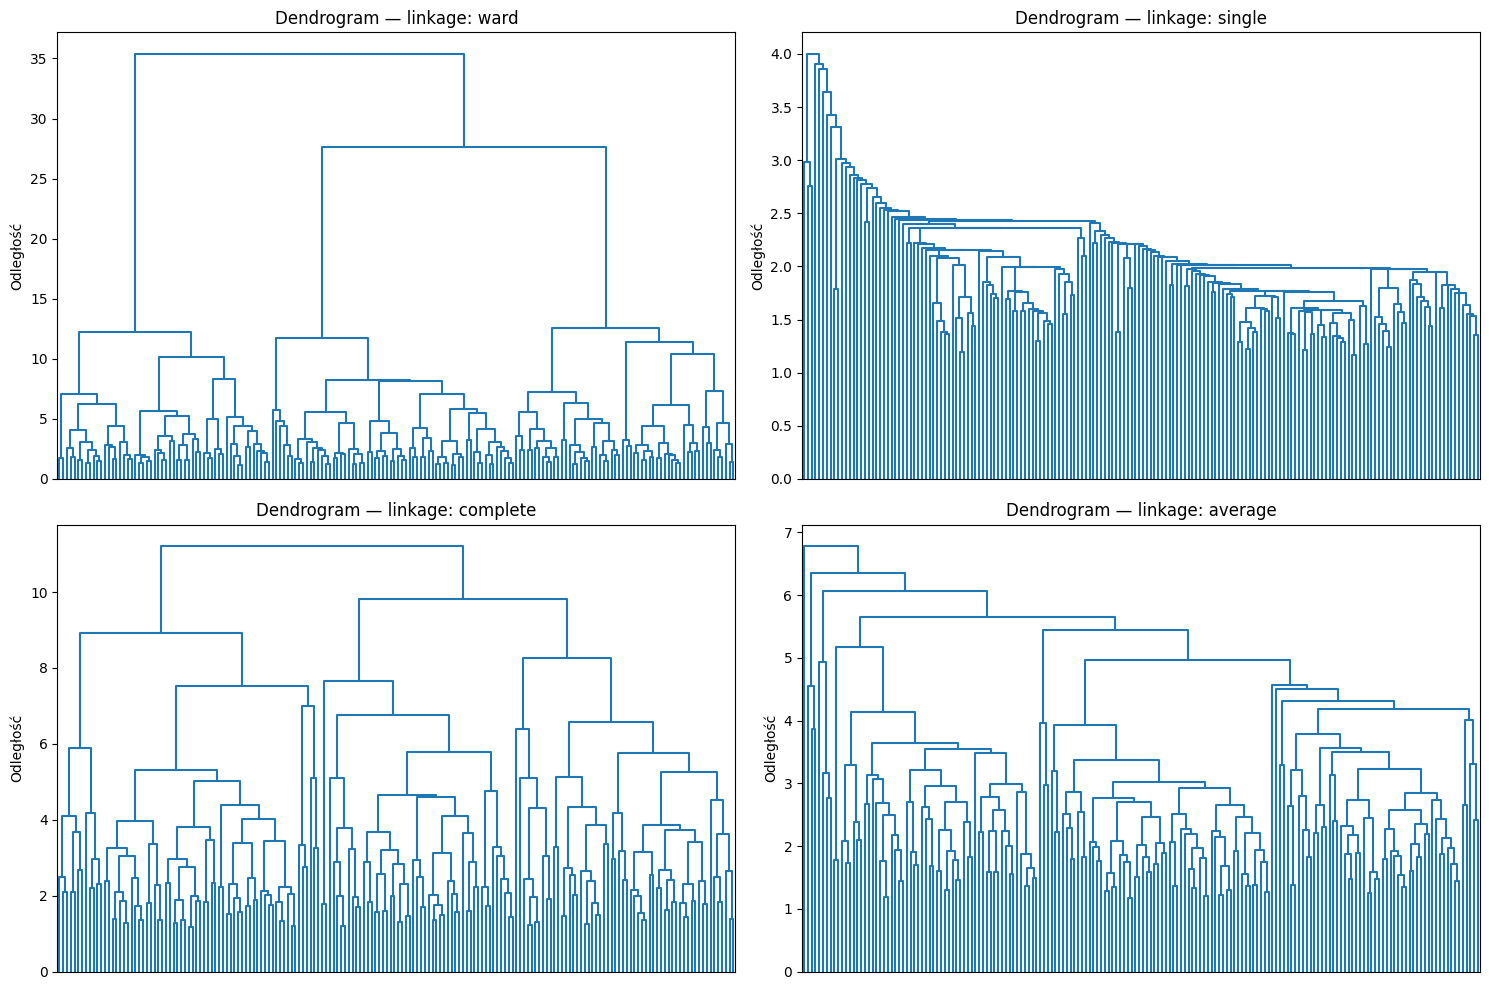

In [10]:
# Porównanie metod łączenia: Ward, single, complete, average
methods = ['ward', 'single', 'complete', 'average']
fig, axes = plt.subplots(2, 2, figsize=(15,10))

for ax, m in zip(axes.flatten(), methods):
    Z = linkage(X_scaled, method=m)
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=0)
    ax.set_title(f'Dendrogram — linkage: {m}')
    ax.set_ylabel('Odległość')
plt.tight_layout(); plt.show()


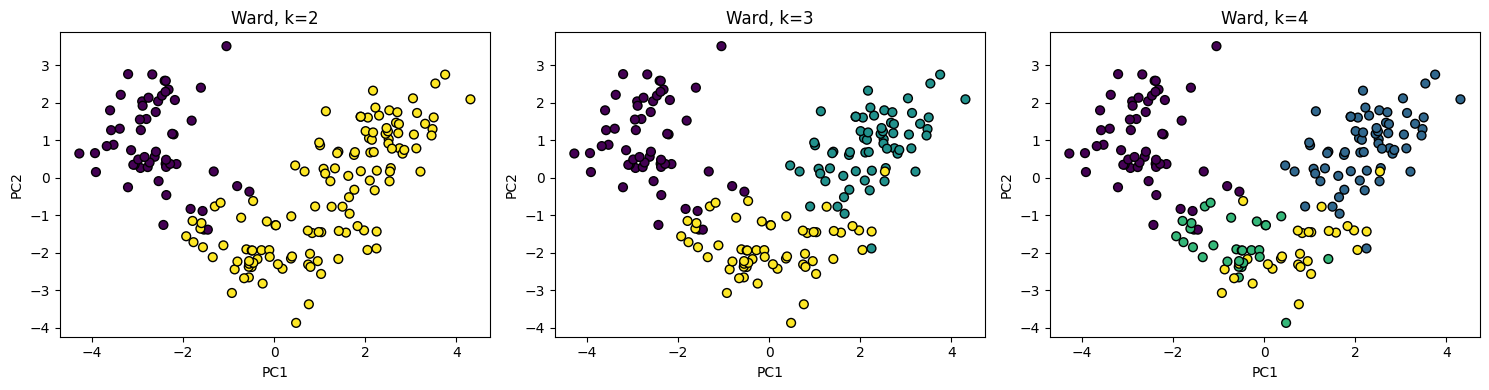

In [11]:
# Wyodrębnianie klastrów na różnych poziomach (Ward) — k = 2, 3, 4
Z_ward = linkage(X_scaled, method='ward')

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, k in zip(axes, [2, 3, 4]):
    cl = fcluster(Z_ward, t=k, criterion='maxclust')
    ax.scatter(X_pca2[:,0], X_pca2[:,1], c=cl, cmap='viridis', s=40, edgecolor='k')
    ax.set_title(f'Ward, k={k}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.show()


ARI(hierarchiczna Ward vs prawdziwe): 0.790
ARI(k-means vs prawdziwe):           0.897
ARI(hierarchiczna vs k-means):       0.853


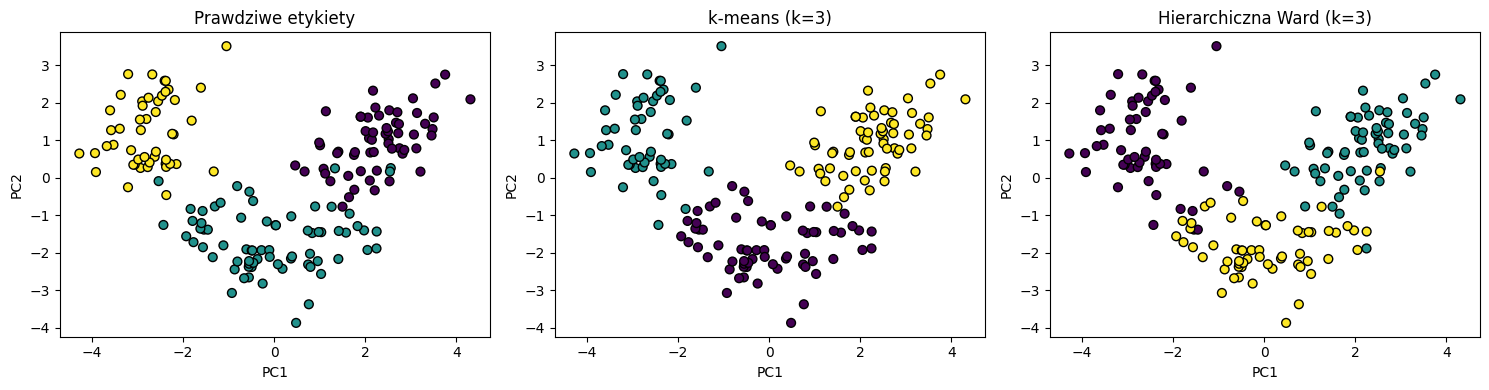

In [12]:
# Porównanie: hierarchiczna (Ward, k=3) vs k-means (k=3) vs prawdziwe etykiety
hc_labels = fcluster(Z_ward, t=3, criterion='maxclust')

print(f'ARI(hierarchiczna Ward vs prawdziwe): {adjusted_rand_score(y_true, hc_labels):.3f}')
print(f'ARI(k-means vs prawdziwe):           {adjusted_rand_score(y_true, km_final.labels_):.3f}')
print(f'ARI(hierarchiczna vs k-means):       {adjusted_rand_score(hc_labels, km_final.labels_):.3f}')

fig, ax = plt.subplots(1, 3, figsize=(15,4))
ax[0].scatter(X_pca2[:,0], X_pca2[:,1], c=y_true, cmap='viridis', s=40, edgecolor='k')
ax[0].set_title('Prawdziwe etykiety')
ax[1].scatter(X_pca2[:,0], X_pca2[:,1], c=km_final.labels_, cmap='viridis', s=40, edgecolor='k')
ax[1].set_title('k-means (k=3)')
ax[2].scatter(X_pca2[:,0], X_pca2[:,1], c=hc_labels, cmap='viridis', s=40, edgecolor='k')
ax[2].set_title('Hierarchiczna Ward (k=3)')
for a in ax: a.set_xlabel('PC1'); a.set_ylabel('PC2')
plt.tight_layout(); plt.show()


### Hierarchiczna na danych po redukcji PCA

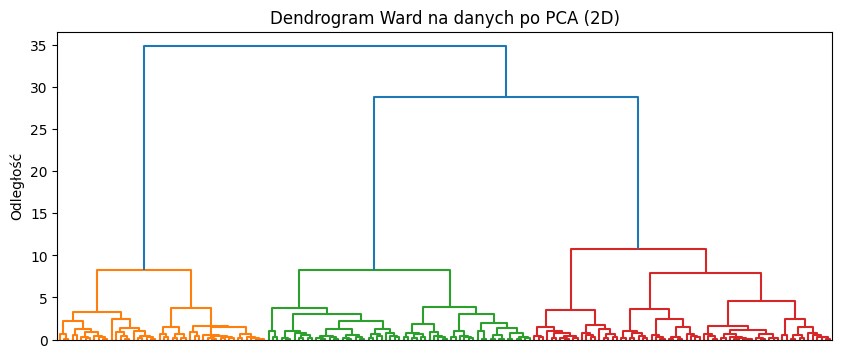

ARI(hierarchiczna na PCA vs prawdziwe): 0.896
ARI(hierarchiczna na PCA vs hier. na pełnych): 0.792


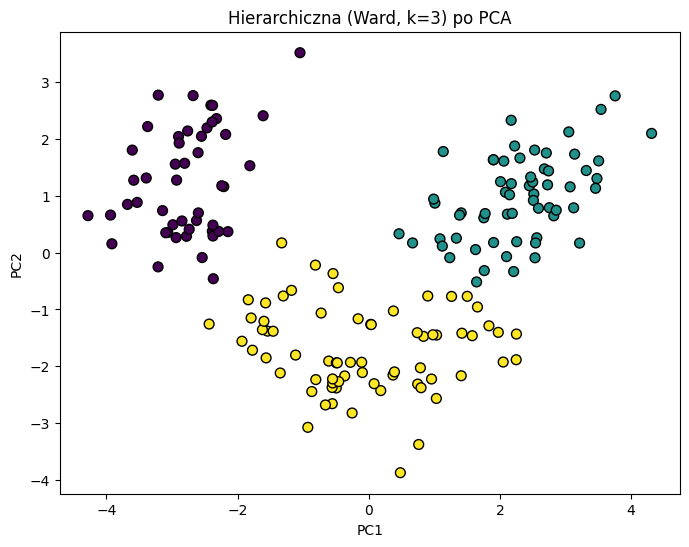

In [13]:
# Klasteryzacja hierarchiczna na PCA (2D) — porównanie z wersją na pełnych danych
Z_ward_pca = linkage(X_pca2, method='ward')

plt.figure(figsize=(10,4))
dendrogram(Z_ward_pca, no_labels=True)
plt.title('Dendrogram Ward na danych po PCA (2D)')
plt.ylabel('Odległość'); plt.show()

hc_pca_labels = fcluster(Z_ward_pca, t=3, criterion='maxclust')
print(f'ARI(hierarchiczna na PCA vs prawdziwe): {adjusted_rand_score(y_true, hc_pca_labels):.3f}')
print(f'ARI(hierarchiczna na PCA vs hier. na pełnych): {adjusted_rand_score(hc_pca_labels, hc_labels):.3f}')

plt.figure(figsize=(8,6))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=hc_pca_labels, cmap='viridis', s=50, edgecolor='k')
plt.title('Hierarchiczna (Ward, k=3) po PCA')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.show()


## Wnioski

- **PCA**: 2 pierwsze składowe wyjaśniają ~55% wariancji, 3 składowe ~67% — wystarczy do czytelnej wizualizacji 3 naturalnych skupień.
- **Klasteryzacja przed vs po PCA**: wyniki k-means są zbliżone (podobne ARI), redukcja wymiarowości ułatwia wizualizację bez znaczącej utraty jakości grupowania.
- **k-means**: metoda łokcia oraz silhouette wskazują **k=3**, zgodnie z rzeczywistą liczbą klas. ARI ≈ 0.9 — bardzo dobre odwzorowanie struktury.
- **Hierarchiczna**: metoda **Ward** daje najbardziej zbalansowane dendrogramy, *single linkage* tworzy efekt łańcuchowy, *complete* — bardziej zwarte ale nierównomierne klastry.
- Hierarchiczna i k-means dają bardzo zbieżne wyniki (ARI ≈ 0.9), co potwierdza istnienie 3 wyraźnych skupień w danych.
